# 15 - Bus Network Analysis

Bus makes up almost all scheduled trips in this feed, but we do not want to assume that the merged graph and the bus graph are structurally identical. In this notebook we isolate regular bus service (`route_type = 3`), build its trip-adjacency graph, and compare it directly with the all-mode network.

We measure the bus layer's components, degree distribution, articulation points, bridges, PageRank, and sampled betweenness. We also compare targeted station removal with random failure and identify the exact stations whose cut-point status changes when the non-bus edges are removed. Demand-responsive bus (`route_type = 715`) stays separate so “bus” has one consistent meaning.

Our main question is: **does the small rail and minor-mode layer actually change where the national network's single points of failure are, even though regular bus supplies almost all trips and edges?**

We use the station and edge tables from notebook 02 plus the raw GTFS route, trip, and stop-time files. The notebook writes a reusable bus graph, directed edge list, station metrics, cut-point and bridge tables, removal curves, bus-versus-all-mode comparisons, and a summary JSON under `outputs/nb/15_bus_network/`.

## 1. Set up the working environment

We find the repository root, switch into it, and define the data and output paths used by every later cell. The helper can clone the repository in Colab and installs only missing packages. Running it again is safe because it does not overwrite analysis outputs.

In [1]:
# --- Environment bootstrap (safe to re-run, works locally and on Google Colab) ---
import os, sys, subprocess
from pathlib import Path

print(f"Python {sys.version.split()[0]} -> {sys.executable}")

def _ensure(*pkgs):
    """Install only the packages that are actually missing."""
    import importlib.util
    alias = {"scikit-learn": "sklearn", "python-louvain": "community",
             "python-bidi": "bidi", "node2vec": "node2vec"}
    missing = [p for p in pkgs
               if importlib.util.find_spec(alias.get(p, p.replace("-", "_"))) is None]
    if missing:
        print("Installing missing packages:", ", ".join(missing))
        print("Using interpreter:", sys.executable)
        subprocess.run([sys.executable, "-m", "pip", "install",
                        "--disable-pip-version-check", *missing],
                       check=True, timeout=900)

def find_repo_root():
    """Find the repo locally; on Colab, clone it."""
    here = Path(os.getcwd()).resolve()
    for cand in [here, *here.parents]:
        if (cand / "israel-public-transportation").is_dir():
            return cand
    target = Path("/content/israel-transit-network-resilience")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/seanfourman/israel-transit-network-resilience.git",
                        str(target)], check=True)
    return target

REPO = find_repo_root()
os.chdir(REPO)
DATA = REPO / "israel-public-transportation"
OUT = REPO / "outputs" / "nb"
OUT.mkdir(parents=True, exist_ok=True)
print("Repo root:", REPO)

Python 3.14.5 -> /Users/seanfourman/Desktop/israel-transit-network-resilience/.venv/bin/python
Repo root: /Users/seanfourman/Desktop/israel-transit-network-resilience


## 2. Load libraries and set runtime controls

We import the graph, data, plotting, and serialization libraries, then create this notebook's table and figure folders. All expensive settings live here so we know exactly what determines the runtime and reproducibility.

`K_BETWEENNESS = 300` uses 300 pivot sources instead of an exact all-source calculation on about 30,000 nodes. We run the same approximation on the bus and all-mode graphs with the same seed so their difference is not just a different sample. The node-removal test uses three fixed targeted orders plus ten random trials at each budget. The one full scan of `stop_times.txt` is usually the longest data-preparation step.

In [2]:
# --- Libraries, stage folders and cost knobs ------------------------------
_ensure('pandas', 'numpy', 'networkx', 'matplotlib', 'seaborn', 'scipy')

import csv, json, pickle, random, time
from collections import defaultdict

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_theme(style='whitegrid', font_scale=1.05)
csv.field_size_limit(10_000_000)   # a handful of rows in stop_times.txt are very long

# --- GTFS mode codes (verified against this feed) -------------------------
BUS_ROUTE_TYPE = '3'      # ordinary bus  : 6,796 routes / 412,544 trips
DRT_ROUTE_TYPE = '715'    # demand-responsive bus : 14 routes / 458 trips

# --- Cost knobs (see the markdown above) ----------------------------------
K_BETWEENNESS = 300                  # betweenness pivots; ~1-3 min per graph
COMPUTE_ALLMODE_BETWEENNESS = True   # False -> skip the second betweenness run
SEED = 42                            # pivots + random removal orderings
RANDOM_TRIALS = 10                   # Monte-Carlo repetitions of random failure
REMOVAL_COUNTS = [0, 10, 25, 50, 100, 250, 500, 1000, 2000, 3000]
PROGRESS_EVERY = 2_000_000           # progress print interval of the streaming pass
FIG_DPI = 150                        # figure resolution
TOP_N = 20                           # rows in every top-N table / bar chart

# --- This stage's own output folder ---------------------------------------
STAGE = OUT / '15_bus_network'
TABLES = STAGE / 'tables'
FIGURES = STAGE / 'figures'
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print('networkx', nx.__version__, '| pandas', pd.__version__)
print('stage folder:', STAGE)

networkx 3.6.1 | pandas 3.0.5
stage folder: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network


## 3. Set up Hebrew text for plots

We choose a font that contains Hebrew glyphs before labeling station figures. This Matplotlib build already handles raw Hebrew strings in the correct direction, so `fix_he` intentionally returns the input unchanged. We keep names in their stored logical order and do not apply an extra bidi reversal.

In [3]:
# Stop names are Hebrew. This matplotlib build applies the Unicode bidi algorithm itself,
# so Hebrew renders correctly when the raw (logical-order) string is passed to matplotlib.
# We do not pre-reorder it with python-bidi because that would reverse it a second time.
# fix_he is a no-op here, and we only select a Hebrew-capable font. (If Hebrew renders
# reversed on some other matplotlib build that has no native bidi, that build would need
# get_display; this one does not.)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.text as mtext

def fix_he(text):
    """No-op: matplotlib reorders Hebrew itself on this build; pre-reordering would reverse it."""
    return text

def install_hebrew():
    # Arial exists on Windows; DejaVu Sans ships with matplotlib and covers Hebrew.
    matplotlib.rcParams["font.family"] = ["Arial", "DejaVu Sans"]
    matplotlib.rcParams["axes.unicode_minus"] = False
    # Write axis numbers as plain decimals - never scientific notation (no "1e-4") and no
    # "+1e-4"-style offset labels, so small values like betweenness read literally.
    matplotlib.rcParams["axes.formatter.useoffset"] = False
    matplotlib.rcParams["axes.formatter.limits"] = (-7, 7)
    # If an earlier run left a bidi patch on Text.set_text, remove it so labels render raw.
    if hasattr(mtext.Text, "_orig_set_text"):
        mtext.Text.set_text = mtext.Text._orig_set_text

install_hebrew()

## 4. Load the all-mode station and edge tables

We load `nodes.csv` and `edges.csv` from the output folder beginning with `02`. The node table supplies names, coordinates, region, metro area, and stop-use counts for bus stations. The edge table is the all-mode comparison graph we rebuild later.

The loader searches both the stage root and subfolders and forces IDs to strings. Missing required files stop the notebook immediately; the softer loader is reserved for optional metric checks. We print sample rows and sizes so we can confirm the schema before attaching attributes to the bus graph.

In [4]:
# --- Locating artifacts written by earlier notebooks ----------------------
def find_stage(prefix, notebook_hint):
    """Return the stage folder whose name starts with `prefix` (e.g. '02')."""
    matches = sorted(p for p in OUT.glob(prefix + '*') if p.is_dir())
    if not matches:
        raise FileNotFoundError(
            f'No stage folder starting with "{prefix}" under {OUT} - '
            f'run notebook {notebook_hint} first.')
    return matches[0]


def find_artifact(stage_dir, filename):
    """Path of `filename` anywhere under a stage folder, or None if absent."""
    direct = stage_dir / filename
    if direct.exists():
        return direct
    matches = sorted(stage_dir.rglob(filename))
    return matches[0] if matches else None


def load_stage_table(prefix, filename, notebook_hint, **kwargs):
    """Read a CSV produced by an earlier stage; fail with an actionable message."""
    stage_dir = find_stage(prefix, notebook_hint)
    path = find_artifact(stage_dir, filename)
    if path is None:
        raise FileNotFoundError(
            f'{filename} not found under {stage_dir} - run notebook {notebook_hint} '
            f'first; it writes {filename}.')
    table = pd.read_csv(path, encoding='utf-8-sig', **kwargs)
    print(f'loaded {filename}: {len(table):,} rows  <-  {path}')
    return table


def try_load_stage_table(prefix, filename, notebook_hint, **kwargs):
    """Optional variant: returns None and prints a note instead of raising."""
    try:
        return load_stage_table(prefix, filename, notebook_hint, **kwargs)
    except FileNotFoundError as exc:
        print('OPTIONAL INPUT MISSING -', exc)
        return None


nodes_all = load_stage_table('02', 'nodes.csv', '02_graph_construction',
                             dtype={'stop_id': str})
edges_all = load_stage_table('02', 'edges.csv', '02_graph_construction',
                             dtype={'from_stop': str, 'to_stop': str})
nodes_all.head()

loaded nodes.csv: 30,463 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/nodes.csv
loaded edges.csv: 51,999 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/02_graph_construction/tables/edges.csv


,stop_id,stop_name,lat,lon,region,metro,stop_use_count
0,38725,ת. רכבת יבנה מערב,31.890700,34.731191,Center,Tel Aviv,1370
1,15582,שד. הסנהדרין/שד. ירושלים,31.887865,34.734514,Center,Tel Aviv,228
2,15746,שד. ירושלים/שד. הסנהדרין,31.887569,34.733548,Center,Tel Aviv,742
3,15725,בית ספר אורמת/נחל חריף,31.894514,34.734783,Center,Tel Aviv,84
4,15416,מחלף בית רבן למזרח,31.819528,34.730697,Center,Tel Aviv,832


## 5. Make sure the large stop-times file is present

We need `stop_times.txt` to reconstruct bus-only adjacency. Because the file is about 816 MB, we download it only if it is absent and then print its local size. The rest of the notebook reads it sequentially rather than loading it into a DataFrame.

In [5]:
# stop_times.txt is 816MB and is not tracked in git - fetch it on demand.
_ensure("gdown")
import gdown
STOP_TIMES = DATA / "stop_times.txt"
if not STOP_TIMES.exists():
    gdown.download(id="1V_yPAWXV6mGTFGrfiosah5LngcLZnviW",
                   output=str(STOP_TIMES), quiet=False)
print("stop_times.txt:", round(STOP_TIMES.stat().st_size / 1024**2, 1), "MB")

stop_times.txt: 778.3 MB


## 6. Identify regular and demand-responsive bus trips

GTFS stores `route_type` on routes rather than trips, so we build the bus trip set by joining `trips.route_id` to `routes.route_id`. Regular bus is exactly code 3. We create a separate set for code 715 instead of folding those flexible services into the fixed bus graph.

We also print the full route-type inventory and count trip records whose route is missing. The missing count is zero in this run. Regular bus contributes 412,544 trips, or 98.19% of all trip records, which explains why we expect the bus topology to look very similar to the merged graph.

In [6]:
# --- Map every trip_id to its GTFS mode -----------------------------------
routes = pd.read_csv(DATA / 'routes.txt', dtype=str, encoding='utf-8-sig')
trips = pd.read_csv(DATA / 'trips.txt', dtype=str, encoding='utf-8-sig')

MODE_LABELS = {'0': 'tram / light rail', '2': 'rail', '3': 'bus',
               '5': 'cable tram', '8': 'trolleybus',
               '715': 'demand-responsive bus'}

route_type_of = dict(zip(routes['route_id'], routes['route_type']))
trips['route_type'] = trips['route_id'].map(route_type_of)
unmapped_trips = int(trips['route_type'].isna().sum())

inventory = (trips.groupby('route_type').size().rename('trips').to_frame()
             .join(routes.groupby('route_type').size().rename('routes'))
             .reset_index())
inventory['mode_label'] = inventory['route_type'].map(MODE_LABELS).fillna('other')
inventory['trip_share'] = (inventory['trips'] / inventory['trips'].sum()).round(4)
inventory = (inventory[['route_type', 'mode_label', 'routes', 'trips', 'trip_share']]
             .sort_values('trips', ascending=False).reset_index(drop=True))

bus_trip_ids = set(trips.loc[trips['route_type'] == BUS_ROUTE_TYPE, 'trip_id'])
drt_trip_ids = set(trips.loc[trips['route_type'] == DRT_ROUTE_TYPE, 'trip_id'])
if not bus_trip_ids:
    raise RuntimeError('No route_type=3 (bus) trips found - check routes.txt / trips.txt.')

# trip_id -> layer label used by the streaming pass below
TRIP_MODE = {tid: 'bus' for tid in bus_trip_ids}
TRIP_MODE.update({tid: 'drt' for tid in drt_trip_ids})

print(f'bus trips (route_type {BUS_ROUTE_TYPE})        : {len(bus_trip_ids):,} '
      f'({len(bus_trip_ids) / len(trips):.2%} of all trips)')
print(f'demand-responsive trips ({DRT_ROUTE_TYPE})     : {len(drt_trip_ids):,}')
print(f'trips with a route_id absent from routes.txt : {unmapped_trips:,}')
inventory

bus trips (route_type 3)        : 412,544 (98.19% of all trips)
demand-responsive trips (715)     : 458
trips with a route_id absent from routes.txt : 0


,route_type,mode_label,routes,trips,trip_share
0,3,bus,6796,412544,0.9819
1,5,cable tram,4,3006,0.0072
2,0,tram / light rail,8,2890,0.0069
3,2,rail,962,1188,0.0028
4,715,demand-responsive bus,14,458,0.0011
5,8,trolleybus,8,47,0.0001


## 7. Stream bus segments from `stop_times.txt`

We scan all 15.7 million rows once with `csv.reader`. At the start of each trip block we check whether the trip belongs to regular bus, demand-responsive bus, or neither. For kept trips, consecutive distinct stops increment a directed edge counter and station call counters. The memory cost grows with unique edges and stops, not with file length.

We count repeated-stop self-loops and every local decrease in `stop_sequence`. This pass retains those row pairs in the edge counter, so we print their number and treat it as an adjacency-quality caveat. There are 562 such transitions among 15.6 million kept rows (about 0.0036%), while notebook 02 found no interleaved trip blocks in the same file. That is too small to invalidate the whole graph, but an exact edge-level use should rebuild after skipping those pairs. We do not parse arrival or departure times here because this notebook only needs topology.

The same pass creates a smaller counter for code 715, letting us describe that layer later without rereading the file. Progress messages show that the scan is active but do not affect the result.

In [7]:
# --- One streaming pass over stop_times.txt, counting segments per mode ----
def stream_mode_edges(path, trip_mode, progress_every=PROGRESS_EVERY):
    """Count directed segments u->v separately for each mode label in `trip_mode`.

    Assumes stop_times.txt is sorted by (trip_id, stop_sequence); the assumption is
    re-checked over every kept row during the same pass.
    Returns (edge_counts, stop_calls, stats).
    """
    modes = sorted(set(trip_mode.values()))
    edge_counts = {m: defaultdict(int) for m in modes}
    stop_calls = {m: defaultdict(int) for m in modes}
    trips_seen = {m: set() for m in modes}
    rows_read = rows_kept = self_loops = seq_regressions = 0
    t0 = time.time()

    with open(path, encoding='utf-8-sig', newline='') as f:
        reader = csv.reader(f)
        header = next(reader)
        for field in ('trip_id', 'stop_id', 'stop_sequence'):
            if field not in header:
                raise ValueError(f'stop_times.txt has no {field} column: {header}')
        ti = header.index('trip_id')
        si = header.index('stop_id')
        qi = header.index('stop_sequence')

        prev_trip, prev_stop, prev_seq, mode = None, None, None, None
        for row in reader:
            rows_read += 1
            if progress_every and rows_read % progress_every == 0:
                print(f'    {rows_read:,} rows | bus segments so far '
                      f'{len(edge_counts["bus"]):,} | {time.time() - t0:,.0f}s')
            trip = row[ti]
            if trip != prev_trip:
                # new trip block: decide its mode once, reset the per-trip state
                prev_trip, prev_stop, prev_seq = trip, None, None
                mode = trip_mode.get(trip)
                if mode is not None:
                    trips_seen[mode].add(trip)
            if mode is None:
                continue                      # a trip of some other mode
            rows_kept += 1
            stop = row[si]
            stop_calls[mode][stop] += 1
            try:
                seq = int(row[qi])
            except (ValueError, IndexError):
                seq = None
            if prev_stop is not None:
                if prev_stop != stop:
                    edge_counts[mode][(prev_stop, stop)] += 1
                else:
                    self_loops += 1
                if seq is not None and prev_seq is not None and seq <= prev_seq:
                    seq_regressions += 1
            prev_stop, prev_seq = stop, seq

    stats = {
        'rows_scanned': rows_read,
        'rows_kept': rows_kept,
        'kept_share_of_feed': round(rows_kept / max(rows_read, 1), 4),
        'self_loops_skipped': self_loops,
        'stop_sequence_regressions': seq_regressions,
        'seconds': round(time.time() - t0, 1),
    }
    for m in modes:
        stats[f'{m}_trips_streamed'] = len(trips_seen[m])
        stats[f'{m}_directed_segments'] = len(edge_counts[m])
        stats[f'{m}_stops_touched'] = len(stop_calls[m])
    return edge_counts, stop_calls, stats


def load_notebook14_mode_cache():
    """Reuse notebook 14's validated one-pass mode split instead of rescanning 778 MiB."""
    try:
        stage14 = find_stage('14', '14_multimodal_inventory')
        edges_path = find_artifact(stage14, 'edges_by_mode.csv')
        calls_path = find_artifact(stage14, 'stop_mode_calls.csv')
        stats_path = find_artifact(stage14, 'stream_stats.json')
        if None in (edges_path, calls_path, stats_path):
            return None
        newest_input = max(p.stat().st_mtime_ns for p in
                           (STOP_TIMES, DATA / 'routes.txt', DATA / 'trips.txt'))
        if min(p.stat().st_mtime_ns for p in (edges_path, calls_path, stats_path)) < newest_input:
            raise ValueError('notebook 14 cache is older than its GTFS inputs')

        cached_edges = pd.read_csv(edges_path, dtype=str, keep_default_na=False,
                                   encoding='utf-8-sig')
        cached_calls = pd.read_csv(calls_path, dtype=str, keep_default_na=False,
                                   encoding='utf-8-sig')
        edge_cols = {'mode_label', 'from_stop', 'to_stop', 'trip_frequency'}
        call_cols = {'mode_label', 'stop_id', 'stop_calls'}
        if not edge_cols.issubset(cached_edges.columns) or not call_cols.issubset(cached_calls.columns):
            raise ValueError('notebook 14 cache has an unexpected schema')

        mode_map = {'bus': 'bus', 'demand/other bus': 'drt'}
        counts = {m: defaultdict(int) for m in ('bus', 'drt')}
        calls = {m: defaultdict(int) for m in ('bus', 'drt')}
        for label, u, v, weight in cached_edges[
                ['mode_label', 'from_stop', 'to_stop', 'trip_frequency']].itertuples(index=False, name=None):
            local = mode_map.get(label)
            if local is not None:
                counts[local][(str(u), str(v))] += int(weight)
        for label, stop, n_calls in cached_calls[
                ['mode_label', 'stop_id', 'stop_calls']].itertuples(index=False, name=None):
            local = mode_map.get(label)
            if local is not None:
                calls[local][str(stop)] += int(n_calls)
        if not counts['bus'] or not calls['bus']:
            raise ValueError('notebook 14 cache contains no bus records')

        with open(stats_path, encoding='utf-8') as handle:
            source_stats = json.load(handle)
        rows_by_mode = source_stats.get('rows_by_mode', {})
        trips_by_mode = source_stats.get('trips_observed', {})
        rows_kept = int(rows_by_mode.get('bus', 0)) + int(rows_by_mode.get('demand/other bus', 0))
        stats = {
            'rows_scanned': int(source_stats.get('rows_read', 0)),
            'rows_kept': rows_kept,
            'kept_share_of_feed': round(rows_kept / max(int(source_stats.get('rows_read', 0)), 1), 4),
            'self_loops_skipped': source_stats.get('self_loop_rows_skipped'),
            'stop_sequence_regressions': None,
            'seconds': 0.0,
            'bus_trips_streamed': int(trips_by_mode.get('bus', 0)),
            'bus_directed_segments': len(counts['bus']),
            'bus_stops_touched': len(calls['bus']),
            'drt_trips_streamed': int(trips_by_mode.get('demand/other bus', 0)),
            'drt_directed_segments': len(counts['drt']),
            'drt_stops_touched': len(calls['drt']),
            'cache_source': str(stage14),
        }
        print('Reusing mode edges and stop calls from notebook 14:', stage14)
        return counts, calls, stats
    except Exception as exc:
        print('Notebook 14 cache unavailable or invalid (' + str(exc) + ').')
        return None


cached_mode_data = load_notebook14_mode_cache()
if cached_mode_data is None:
    print('Falling back to one streaming pass over stop_times.txt ...', flush=True)
    edge_counts, stop_calls, stream_stats = stream_mode_edges(STOP_TIMES, TRIP_MODE)
else:
    edge_counts, stop_calls, stream_stats = cached_mode_data
print(json.dumps(stream_stats, indent=2))
if stream_stats.get('stop_sequence_regressions'):
    n_regressions = int(stream_stats['stop_sequence_regressions'])
    regression_share = n_regressions / max(int(stream_stats['rows_kept']), 1)
    print(f'\nNOTE: {n_regressions:,} local stop_sequence regressions '
          f'({regression_share:.4%} of kept rows).')
    print('The current edge counts retain these transitions, so we keep them as a small '
          'adjacency-quality caveat.')

Reusing mode edges and stop calls from notebook 14: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory
{
  "rows_scanned": 15711624,
  "rows_kept": 15615766,
  "kept_share_of_feed": 0.9939,
  "self_loops_skipped": 718,
  "stop_sequence_regressions": null,
  "seconds": 0.0,
  "bus_trips_streamed": 412544,
  "bus_directed_segments": 51503,
  "bus_stops_touched": 30170,
  "drt_trips_streamed": 458,
  "drt_directed_segments": 197,
  "drt_stops_touched": 153,
  "cache_source": "/Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/14_multimodal_inventory"
}


## 8. Build the directed and undirected bus graphs

We convert the counters into `D_bus`, where edge direction follows trip order and weight is the number of bus trips on that segment. We then create `G_bus` by combining both directions and summing their weights. Connectivity, cut points, bridges, and node-removal tests all use this undirected graph.

We attach names, coordinates, region, and metro attributes from the all-mode node table. The conversion helpers turn missing numeric values into `None` rather than leaving `NaN` inside the graph. In this run the graph has 30,169 nodes, 51,503 directed edges, and 51,387 undirected edges, with no graph node missing its station attributes.

In [8]:
# --- Build the bus graphs and attach stop attributes ----------------------
def build_graphs(counts):
    """Directed trip-adjacency graph plus its summed undirected projection."""
    D = nx.DiGraph()
    for (u, v), w in counts.items():
        D.add_edge(u, v, weight=int(w))
    G = nx.Graph()
    for u, v, data in D.edges(data=True):
        if G.has_edge(u, v):
            G[u][v]['weight'] += data['weight']
        else:
            G.add_edge(u, v, weight=data['weight'])
    return G, D


def _num(value):
    """Coerce to float; None for blanks, NaN or non-numeric input."""
    try:
        f = float(value)
    except (TypeError, ValueError):
        return None
    return None if not np.isfinite(f) else f


def _txt(value):
    """Coerce to a plain string; NaN and None become an empty string."""
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return ''
    return str(value)


ATTR = {str(r.get('stop_id')): {'stop_name': _txt(r.get('stop_name')),
                                'lat': _num(r.get('lat')),
                                'lon': _num(r.get('lon')),
                                'region': _txt(r.get('region')),
                                'metro': _txt(r.get('metro'))}
        for r in nodes_all.to_dict('records')}
DEFAULT_ATTR = {'stop_name': '', 'lat': None, 'lon': None, 'region': '', 'metro': ''}

G_bus, D_bus = build_graphs(edge_counts['bus'])
for graph in (G_bus, D_bus):
    for n in graph.nodes():
        graph.nodes[n].update(ATTR.get(n, DEFAULT_ATTR))

missing_attr = [n for n in G_bus.nodes() if n not in ATTR]
stops_without_segments = sorted(set(stop_calls['bus']) - set(G_bus.nodes()))

print(f'bus undirected : {G_bus.number_of_nodes():,} nodes, {G_bus.number_of_edges():,} edges')
print(f'bus directed   : {D_bus.number_of_nodes():,} nodes, {D_bus.number_of_edges():,} edges')
print(f'bus stops served by a trip but with no segment (excluded from V): '
      f'{len(stops_without_segments):,}')
print(f'bus nodes with no attributes in stage-02 nodes.csv: {len(missing_attr):,}')

bus undirected : 30,169 nodes, 51,387 edges
bus directed   : 30,169 nodes, 51,503 edges
bus stops served by a trip but with no segment (excluded from V): 1
bus nodes with no attributes in stage-02 nodes.csv: 0


## 9. Measure the bus graph's overall structure

We calculate the same basic quantities we use for the national graph: node and edge counts, density, degree summaries, components, largest-component share, articulation points, and bridges. The cut structures are exact linear-time graph calculations, so there is no need to sample them.

The printed values give the baseline for the rest of the notebook. The bus graph is almost completely connected: 30,165 of 30,169 nodes are in its largest component. It has 754 articulation points (2.50% of nodes) and 812 bridges (1.58% of edges), while 44.41% of stations have degree two or less. This combination suggests a well-connected core with many thin branches.

In [9]:
# --- Global structure of the bus network ----------------------------------
def structure_summary(G, D=None):
    """Size / sparsity / fragmentation / single-point-of-failure counts."""
    degrees = np.array([d for _, d in G.degree()])
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    largest = len(components[0])
    ap = set(nx.articulation_points(G))
    br = list(nx.bridges(G))
    summary = {
        'nodes': G.number_of_nodes(),
        'edges_undirected': G.number_of_edges(),
        'edges_directed': D.number_of_edges() if D is not None else None,
        'density': round(nx.density(G), 6),
        'avg_degree': round(float(degrees.mean()), 3),
        'median_degree': float(np.median(degrees)),
        'max_degree': int(degrees.max()),
        'share_degree_le_2': round(float((degrees <= 2).mean()), 4),
        'connected_components': len(components),
        'largest_component_nodes': largest,
        'largest_component_share': round(largest / G.number_of_nodes(), 4),
        'articulation_points': len(ap),
        'articulation_point_share': round(len(ap) / G.number_of_nodes(), 4),
        'bridges': len(br),
        'bridge_share': round(len(br) / G.number_of_edges(), 4),
    }
    return summary, ap, br


bus_stats, ap_bus, bridges_bus = structure_summary(G_bus, D_bus)
deg_bus = dict(G_bus.degree())

for key, value in bus_stats.items():
    print(f'{key:28s} {value}')
pd.DataFrame([bus_stats])

nodes                        30169
edges_undirected             51387
edges_directed               51503
density                      0.000113
avg_degree                   3.407
median_degree                3.0
max_degree                   62
share_degree_le_2            0.4441
connected_components         2
largest_component_nodes      30165
largest_component_share      0.9999
articulation_points          754
articulation_point_share     0.025
bridges                      812
bridge_share                 0.0158


,nodes,edges_undirected,edges_directed,density,avg_degree,median_degree,max_degree,share_degree_le_2,connected_components,largest_component_nodes,largest_component_share,articulation_points,articulation_point_share,bridges,bridge_share
0,30169,51387,51503,0.000113,3.407,3.0,62,0.4441,2,30165,0.9999,754,0.025,812,0.0158


## 10. Calculate station centrality

We calculate four complementary station scores. Degree counts distinct adjacent stations, weighted degree sums bus-trip frequency, PageRank follows directed weighted service flow, and betweenness estimates how often a station lies on shortest hop paths.

Betweenness is the only approximate metric here. Exact calculation would require a shortest-path sweep from every bus node, so we sample 300 sources with a fixed seed. The head of the ranking is useful, but we should not interpret tiny differences among low-scoring stations as precise. The paths are unweighted by time; scheduled minutes are introduced in notebook 18.

We join the scores and attributes into `bus_station_metrics.csv`, add rank columns, and mark articulation points so busy hubs and structural bottlenecks can be compared in one table.

In [10]:
# --- Centrality on the bus graph (the expensive part is betweenness) ------
t0 = time.time()
wdeg_bus = dict(G_bus.degree(weight='weight'))
pagerank_bus = nx.pagerank(D_bus, weight='weight')
k_bus = min(K_BETWEENNESS, G_bus.number_of_nodes())
btw_bus = nx.betweenness_centrality(G_bus, k=k_bus, seed=SEED,
                                    normalized=True, weight=None)
print(f'centrality computed in {time.time() - t0:,.0f}s '
      f'(betweenness pivots: {k_bus} of {G_bus.number_of_nodes():,} nodes)')

bus_metrics = pd.DataFrame([{
    'stop_id': n,
    'stop_name': G_bus.nodes[n]['stop_name'],
    'lat': G_bus.nodes[n]['lat'],
    'lon': G_bus.nodes[n]['lon'],
    'region': G_bus.nodes[n]['region'],
    'degree': int(deg_bus[n]),
    'weighted_degree': int(wdeg_bus[n]),
    'approx_betweenness': float(btw_bus[n]),
    'is_articulation_point': n in ap_bus,
    'metro': G_bus.nodes[n]['metro'],
    'pagerank': float(pagerank_bus[n]),
    'in_degree': int(D_bus.in_degree(n)),
    'out_degree': int(D_bus.out_degree(n)),
    'bus_stop_calls': int(stop_calls['bus'].get(n, 0)),
} for n in G_bus.nodes()])

for col in ('degree', 'weighted_degree', 'approx_betweenness', 'pagerank'):
    bus_metrics['rank_' + col] = (bus_metrics[col]
                                  .rank(ascending=False, method='min').astype(int))

bus_metrics = (bus_metrics.sort_values('approx_betweenness', ascending=False)
               .reset_index(drop=True))
bus_metrics.to_csv(TABLES / 'bus_station_metrics.csv', index=False, encoding='utf-8-sig')
print('saved:', TABLES / 'bus_station_metrics.csv')
bus_metrics.head(10)

centrality computed in 13s (betweenness pivots: 300 of 30,169 nodes)
saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/tables/bus_station_metrics.csv


,stop_id,stop_name,lat,lon,region,degree,weighted_degree,approx_betweenness,is_articulation_point,metro,pagerank,in_degree,out_degree,bus_stop_calls,rank_degree,rank_weighted_degree,rank_approx_betweenness,rank_pagerank
0,17303,ת.התרעננות/דור אלון מגל 6,32.380891,35.017969,Center,16,220,0.116284,False,Periphery,0.000010,9,7,110,78,21881,1,28339
1,27689,מחלף קמה לצפון,31.442254,34.766984,South,24,1304,0.076941,False,Beer Sheva,0.000093,10,14,652,19,7348,2,506
2,41132,מחלף חמד,31.800330,35.126238,Jerusalem,44,10540,0.073327,False,Jerusalem,0.000400,32,12,5339,2,48,3,1
3,7444,דרך האר''י/ כביש 375,31.704533,35.126243,Jerusalem,29,5272,0.072353,False,Jerusalem,0.000056,7,22,2654,11,555,4,3145
4,41133,מחלף חמד,31.801002,35.124540,Jerusalem,62,10454,0.072129,True,Jerusalem,0.000126,25,37,5289,1,49,5,117
5,7562,שדרות בית הלל/כניסה לעיר,31.936583,35.035446,Center,29,3870,0.066418,False,Tel Aviv,0.000083,24,5,1935,11,1362,6,809
6,9048,בן גוריון/שערי ירושלים,31.791535,35.196465,Jerusalem,41,9472,0.052230,True,Jerusalem,0.000086,18,23,4736,3,79,7,723
7,748,מחלף קסם,32.119458,34.938360,Center,19,1534,0.044462,False,Tel Aviv,0.000060,12,7,767,40,6170,8,2579
8,29243,תחנת התרעננות/פונדק בית קמה,31.442304,34.764124,South,19,520,0.042037,False,Beer Sheva,0.000027,10,9,260,40,14826,9,17257
9,18691,צומת ראש פינה,32.968266,35.551334,North,13,2010,0.040001,False,Periphery,0.000114,7,6,1005,175,4385,10,196


## 11. Compare the top stations under different definitions

No single centrality measure means “most important,” so we take the union of the top 20 stations by degree, weighted degree, PageRank, and sampled betweenness. The table shows every rank for each selected station and whether it is also a cut point.

The figure puts service volume and path bottleneck side by side. In this run 66 distinct stations appear in at least one top-20 list and only 12 are articulation points. That separation is useful: a station can be extremely busy without being a single point of failure, or have high betweenness with relatively little local service.

66 distinct stations appear in at least one top-20 list
of which 12 are also bus cut vertices


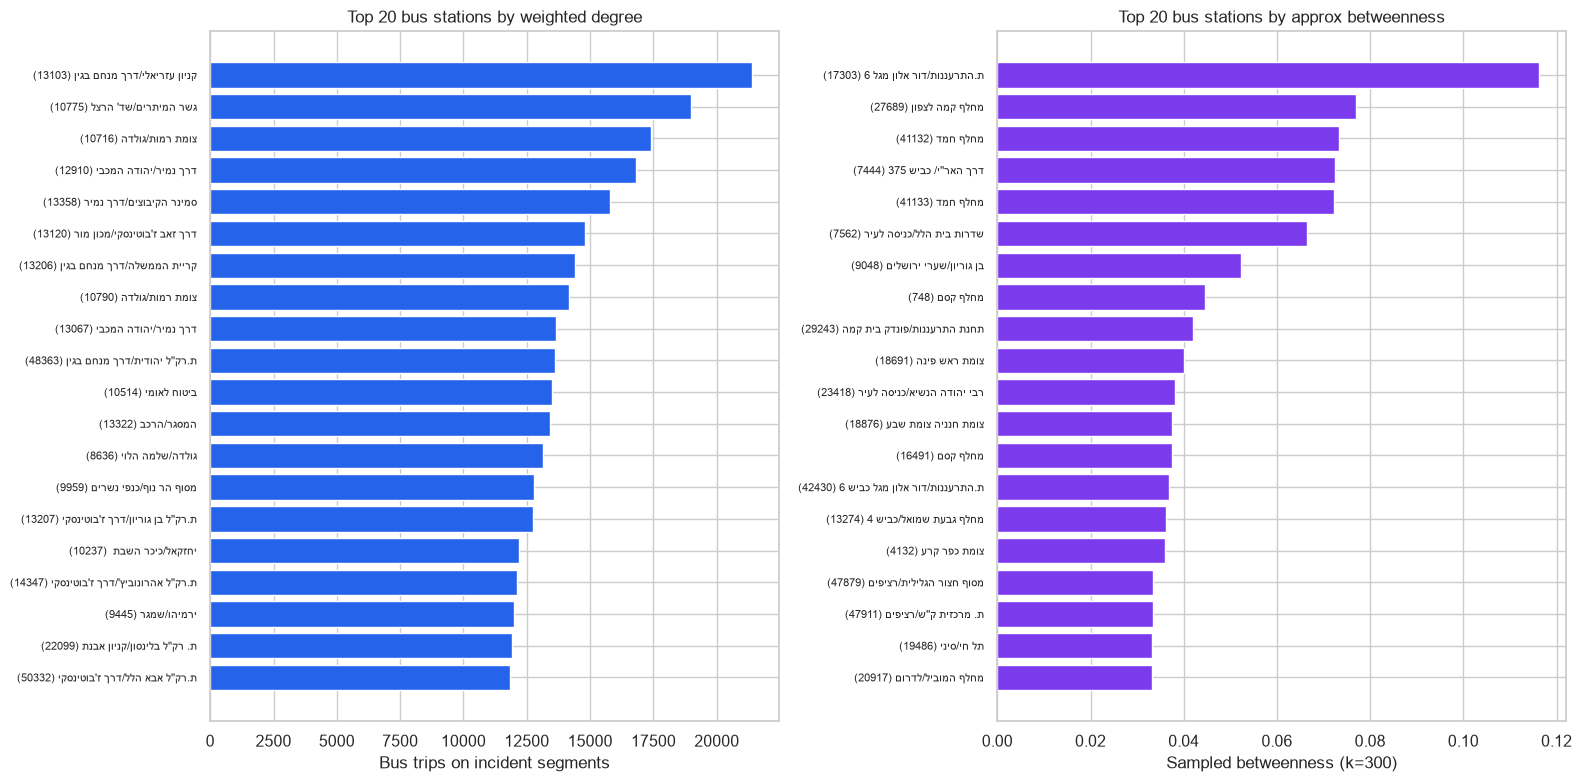

,stop_id,stop_name,region,metro,degree,weighted_degree,approx_betweenness,pagerank,is_articulation_point,rank_degree,rank_weighted_degree,rank_approx_betweenness,rank_pagerank
0,17303,ת.התרעננות/דור אלון מגל 6,Center,Periphery,16,220,0.116284,0.000010,False,78,21881,1,28339
1,27689,מחלף קמה לצפון,South,Beer Sheva,24,1304,0.076941,0.000093,False,19,7348,2,506
2,41132,מחלף חמד,Jerusalem,Jerusalem,44,10540,0.073327,0.000400,False,2,48,3,1
3,7444,דרך האר''י/ כביש 375,Jerusalem,Jerusalem,29,5272,0.072353,0.000056,False,11,555,4,3145
4,41133,מחלף חמד,Jerusalem,Jerusalem,62,10454,0.072129,0.000126,True,1,49,5,117
5,7562,שדרות בית הלל/כניסה לעיר,Center,Tel Aviv,29,3870,0.066418,0.000083,False,11,1362,6,809
6,9048,בן גוריון/שערי ירושלים,Jerusalem,Jerusalem,41,9472,0.052230,0.000086,True,3,79,7,723
7,748,מחלף קסם,Center,Tel Aviv,19,1534,0.044462,0.000060,False,40,6170,8,2579
8,29243,תחנת התרעננות/פונדק בית קמה,South,Beer Sheva,19,520,0.042037,0.000027,False,40,14826,9,17257
9,18691,צומת ראש פינה,North,Periphery,13,2010,0.040001,0.000114,False,175,4385,10,196


In [11]:
# --- Top bus stations under four rankings ---------------------------------
rank_cols = ['rank_degree', 'rank_weighted_degree', 'rank_approx_betweenness',
             'rank_pagerank']
top_mask = (bus_metrics[rank_cols] <= TOP_N).any(axis=1)
top_table = (bus_metrics[top_mask]
             .sort_values('rank_approx_betweenness')
             [['stop_id', 'stop_name', 'region', 'metro', 'degree', 'weighted_degree',
               'approx_betweenness', 'pagerank', 'is_articulation_point'] + rank_cols]
             .reset_index(drop=True))
top_table.to_csv(TABLES / 'top_bus_stations.csv', index=False, encoding='utf-8-sig')
print(f'{len(top_table)} distinct stations appear in at least one top-{TOP_N} list')
print(f"of which {int(top_table['is_articulation_point'].sum())} are also bus cut vertices")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
panels = [('weighted_degree', 'Bus trips on incident segments', '#2563eb'),
          ('approx_betweenness', f'Sampled betweenness (k={k_bus})', '#7c3aed')]
for ax, (col, xlabel, colour) in zip(axes, panels):
    panel = bus_metrics.sort_values(col, ascending=False).head(TOP_N).iloc[::-1]
    labels = [f'{name} ({sid})' for name, sid in zip(panel['stop_name'], panel['stop_id'])]
    ax.barh(range(len(panel)), panel[col].to_numpy(), color=colour)
    ax.set_yticks(range(len(panel)))
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_title(f'Top {TOP_N} bus stations by {col.replace("_", " ")}')
plt.tight_layout()
plt.savefig(FIGURES / 'top_bus_stations.png', dpi=FIG_DPI)
plt.show()

top_table.head(TOP_N)

## 12. Export bus cut vertices and bridges

We save every articulation point with station attributes and centrality values, and every bridge with both endpoint names and trip frequency. An articulation point splits its connected component when removed; a bridge is the only edge joining two parts of a component.

These are topological flags, not direct damage estimates. The median bus cut vertex has degree 3, so many are on small peripheral branches. We sort and display the higher-degree cut points and busiest bridges to separate major transfer structures from cases where only a few terminal stops become isolated.

In [12]:
# --- Export bus cut vertices and cut edges --------------------------------
ap_table = (bus_metrics[bus_metrics['is_articulation_point']]
            [['stop_id', 'stop_name', 'lat', 'lon', 'region', 'metro',
              'degree', 'weighted_degree', 'approx_betweenness']]
            .sort_values('degree', ascending=False).reset_index(drop=True))
ap_table.to_csv(TABLES / 'bus_articulation_points.csv', index=False, encoding='utf-8-sig')

name_of = {n: (G_bus.nodes[n].get('stop_name') or n) for n in G_bus.nodes()}
bridge_table = pd.DataFrame([{
    'from_stop': u,
    'to_stop': v,
    'from_name': name_of[u],
    'to_name': name_of[v],
    'trip_frequency': int(G_bus[u][v]['weight']),
} for u, v in bridges_bus]).sort_values('trip_frequency', ascending=False).reset_index(drop=True)
bridge_table.to_csv(TABLES / 'bus_bridges.csv', index=False, encoding='utf-8-sig')

print(f"bus articulation points : {len(ap_table):,} "
      f"({len(ap_table) / G_bus.number_of_nodes():.2%} of bus stops)")
print(f"bus bridges             : {len(bridge_table):,} "
      f"({len(bridge_table) / G_bus.number_of_edges():.2%} of undirected segments)")
print(f"median degree of a bus cut vertex: {ap_table['degree'].median():.0f}")
print('\nHighest-degree bus cut vertices:')
display(ap_table.head(TOP_N))
print('Busiest bus bridges:')
bridge_table.head(TOP_N)

bus articulation points : 754 (2.50% of bus stops)
bus bridges             : 812 (1.58% of undirected segments)
median degree of a bus cut vertex: 3

Highest-degree bus cut vertices:


,stop_id,stop_name,lat,lon,region,metro,degree,weighted_degree,approx_betweenness
0,41133,מחלף חמד,31.801002,35.124540,Jerusalem,Jerusalem,62,10454,0.072129
1,9048,בן גוריון/שערי ירושלים,31.791535,35.196465,Jerusalem,Jerusalem,41,9472,0.052230
2,10775,גשר המיתרים/שד' הרצל,31.787162,35.199533,Jerusalem,Jerusalem,37,18976,0.009830
3,12975,מחלף לה גווארדייה,32.059454,34.786354,Center,Tel Aviv,34,6604,0.021966
4,13246,בית ספר הולץ/חיל השריון,32.046238,34.783261,Center,Tel Aviv,31,9154,0.022384
5,13322,המסגר/הרכב,32.063660,34.785580,Center,Tel Aviv,27,13424,0.000837
6,9553,גשר המיתרים/שד' הרצל,31.787322,35.199369,Jerusalem,Jerusalem,22,10314,0.008607
7,27623,מרכז רפואי סורוקה/אוניברסיטת בן גוריון,31.259220,34.798363,South,Beer Sheva,20,4594,0.025774
8,14355,מחלף מורשה,32.123726,34.854708,Center,Tel Aviv,20,2116,0.021384
9,13356,דרך קיבוץ גלויות/כביש 1,32.046861,34.784605,Center,Tel Aviv,20,3334,0.009484


Busiest bus bridges:


,from_stop,to_stop,from_name,to_name,trip_frequency
0,23299,23298,ת. רכבת קרית אריה,ת. רכבת קרית אריה,1809
1,11448,48932,מסוף חומת שמואל/אליהו קורן,תחנה תפעולית/היציאה מחניון חומת שמואל,1672
2,10532,48933,רב החובל/אדם,תחנה תפעולית/חניון תלפיות מזרח,1575
3,49466,10576,מסוף הר נוף/כנפי נשרים,מסוף הר נוף/בית הדפוס,1306
4,25712,50730,שוק עירוני/בית אשל,ת.מרכזית/עירוניים לצפון,1210
5,47884,28884,בית העלמין החדש,מסוף חצרים,1154
6,25467,49279,כיכר הטפטפת/דרך ג'ו יוסף אלון,מסוף חצרים,1145
7,48462,48461,הרטום/גולדה מאיר,חניון הרטום,1057
8,37624,37623,הנפח/מעלה כמון,הנפח/היזם,1037
9,37608,37607,חניון אגד/הנפח,הנפח/מעלה כמון,1037


## 13. Simulate targeted and random station removal

We remove stations in four fixed orders and measure the surviving largest component as a share of the original bus-node count. The targeted orders use descending degree, descending sampled betweenness, and articulation points first; the random curve averages ten shuffled orders and records their standard deviation.

The rankings are calculated once on the intact graph and are not updated after each deletion. This keeps the experiment affordable but makes targeted damage less severe than an adaptive strategy could achieve. Betweenness ordering also inherits the 300-source sampling noise.

The gap between targeted and random curves is the result we care about. At 3,000 removals, the random mean still keeps about 86.2% of the original nodes in the largest component, while the targeted curves leave only about 34.7%-39.7%.

removal experiment finished in 6s


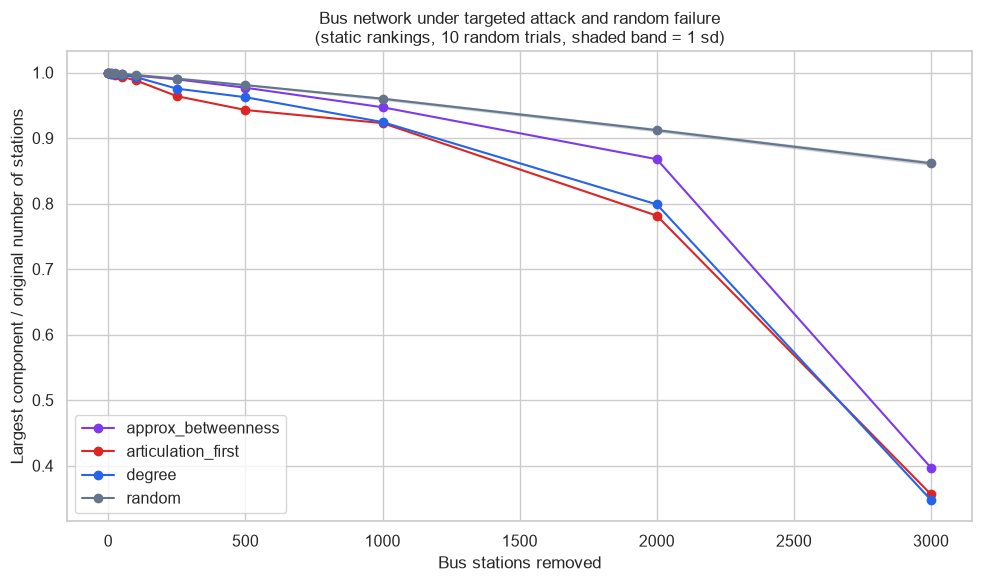

strategy,approx_betweenness,articulation_first,degree,random
removed,,,,
0,0.99987,0.99987,0.99987,0.99987
10,0.99877,0.99831,0.99838,0.99953
25,0.99818,0.99609,0.99751,0.99901
50,0.99698,0.99334,0.99615,0.99815
100,0.99523,0.98807,0.99307,0.99627
250,0.98959,0.96390,0.97537,0.99075
500,0.97680,0.94282,0.96231,0.98084
1000,0.94697,0.92280,0.92433,0.96002
2000,0.86771,0.78153,0.79873,0.91208


In [13]:
# --- Targeted vs random node removal --------------------------------------
def resilience_curve(graph, order, counts):
    """Largest-component share (of the ORIGINAL node count) after removing order[:c]."""
    n0 = graph.number_of_nodes()
    all_nodes = set(graph.nodes())
    shares = []
    for c in counts:
        remaining = all_nodes - set(order[:c])
        if not remaining:
            shares.append(0.0)
            continue
        sizes = [len(comp) for comp
                 in nx.connected_components(graph.subgraph(remaining))]
        shares.append(max(sizes) / n0)
    return shares


strategies = {
    'degree': bus_metrics.sort_values(['degree', 'weighted_degree'],
                                      ascending=False)['stop_id'].tolist(),
    'approx_betweenness': bus_metrics.sort_values('approx_betweenness',
                                                  ascending=False)['stop_id'].tolist(),
    'articulation_first': bus_metrics.sort_values(['is_articulation_point', 'degree'],
                                                  ascending=False)['stop_id'].tolist(),
}

t0 = time.time()
rows = []
for name, order in strategies.items():
    for c, share in zip(REMOVAL_COUNTS, resilience_curve(G_bus, order, REMOVAL_COUNTS)):
        rows.append({'strategy': name, 'removed': c,
                     'largest_component_share': round(share, 5),
                     'std_across_trials': 0.0})

rng = random.Random(SEED)
node_list = list(G_bus.nodes())
random_curves = []
for _ in range(RANDOM_TRIALS):
    shuffled = node_list[:]
    rng.shuffle(shuffled)
    random_curves.append(resilience_curve(G_bus, shuffled, REMOVAL_COUNTS))
random_mean = np.mean(random_curves, axis=0)
random_std = np.std(random_curves, axis=0)
for c, m, s in zip(REMOVAL_COUNTS, random_mean, random_std):
    rows.append({'strategy': 'random', 'removed': c,
                 'largest_component_share': round(float(m), 5),
                 'std_across_trials': round(float(s), 5)})

resilience = pd.DataFrame(rows)
resilience.to_csv(TABLES / 'bus_resilience.csv', index=False, encoding='utf-8-sig')
print(f'removal experiment finished in {time.time() - t0:,.0f}s')

fig, ax = plt.subplots(figsize=(10, 6))
colours = {'degree': '#2563eb', 'approx_betweenness': '#7c3aed',
           'articulation_first': '#dc2626', 'random': '#64748b'}
for name, grp in resilience.groupby('strategy'):
    grp = grp.sort_values('removed')
    ax.plot(grp['removed'], grp['largest_component_share'], marker='o',
            color=colours.get(name), label=name)
    if name == 'random':
        ax.fill_between(grp['removed'],
                        grp['largest_component_share'] - grp['std_across_trials'],
                        grp['largest_component_share'] + grp['std_across_trials'],
                        color=colours['random'], alpha=0.25)
ax.set_xlabel('Bus stations removed')
ax.set_ylabel('Largest component / original number of stations')
ax.set_title('Bus network under targeted attack and random failure\n'
             f'(static rankings, {RANDOM_TRIALS} random trials, shaded band = 1 sd)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / 'bus_resilience_curves.png', dpi=FIG_DPI)
plt.show()

resilience.pivot(index='removed', columns='strategy',
                 values='largest_component_share')

## 14. Rebuild the all-mode baseline with the same measurements

We construct the undirected all-mode graph from notebook 02's directed edge table and run the same structure function used for `G_bus`. When enabled, we also estimate all-mode betweenness using the same `k = 300` and seed as the bus calculation. That makes the rank comparison much cleaner than mixing samples produced with different settings.

We optionally compare our recomputed cut vertices and sampled betweenness with the saved notebook 03 and 04 tables. In this run all 900 all-mode cut vertices match, and two independent betweenness samples correlate at Spearman 0.960, which gives us a sense of the remaining sampling variability.

The side-by-side table shows that bus covers 99.03% of nodes and 99.26% of undirected edges in the merged graph.

In [14]:
# --- Rebuild and re-measure the all-mode network --------------------------
D_all = nx.DiGraph()
for rec in edges_all.to_dict('records'):
    D_all.add_edge(str(rec['from_stop']), str(rec['to_stop']),
                   weight=int(rec.get('trip_frequency', 1)))
G_all = nx.Graph()
for u, v, data in D_all.edges(data=True):
    if G_all.has_edge(u, v):
        G_all[u][v]['weight'] += data['weight']
    else:
        G_all.add_edge(u, v, weight=data['weight'])
for n in G_all.nodes():
    G_all.nodes[n].update(ATTR.get(n, DEFAULT_ATTR))

all_stats, ap_all, bridges_all = structure_summary(G_all, D_all)
deg_all = dict(G_all.degree())

btw_all = None
reused_nb04_betweenness = False
metrics04 = try_load_stage_table('04', 'stop_metrics.csv', '04_centrality_analysis',
                                 dtype={'stop_id': str})
if metrics04 is not None and 'approx_betweenness' in metrics04.columns:
    btw_all = dict(zip(metrics04['stop_id'],
                       pd.to_numeric(metrics04['approx_betweenness'], errors='coerce').fillna(0.0)))
    reused_nb04_betweenness = True
    print('reusing all-mode betweenness from notebook 04')
elif COMPUTE_ALLMODE_BETWEENNESS:
    t0 = time.time()
    btw_all = nx.betweenness_centrality(G_all, k=min(K_BETWEENNESS, G_all.number_of_nodes()),
                                        seed=SEED, normalized=True, weight=None)
    print(f'all-mode betweenness computed in {time.time() - t0:,.0f}s')
else:
    print('all-mode betweenness skipped (COMPUTE_ALLMODE_BETWEENNESS = False)')

# --- optional cross-checks against notebooks 03 and 04 --------------------
ap03 = try_load_stage_table('03', 'articulation_points.csv', '03_descriptive_analysis',
                            dtype={'stop_id': str})
if ap03 is not None:
    ap03_ids = set(ap03['stop_id'])
    print(f'cross-check vs notebook 03: it lists {len(ap03_ids):,} cut vertices, '
          f'We recomputed {len(ap_all):,}; {len(ap03_ids & ap_all):,} agree')

if (metrics04 is not None and btw_all is not None and not reused_nb04_betweenness
        and 'approx_betweenness' in metrics04):
    joint = metrics04[['stop_id', 'approx_betweenness']].dropna()
    joint = joint[joint['stop_id'].isin(btw_all)]
    rho04, _ = spearmanr(joint['approx_betweenness'],
                         [btw_all[s] for s in joint['stop_id']])
    print(f'cross-check vs notebook 04: Spearman rho between its all-mode '
          f'approx_betweenness and our estimate = {rho04:.3f} over {len(joint):,} stops')

comparison = pd.DataFrame({'metric': list(bus_stats.keys()),
                           'bus_only': list(bus_stats.values()),
                           'all_modes': [all_stats[k] for k in bus_stats]})
comparison['bus_share_of_all'] = [
    round(b / a, 4) if isinstance(b, (int, float)) and isinstance(a, (int, float)) and a
    else None
    for b, a in zip(comparison['bus_only'], comparison['all_modes'])]
comparison.to_csv(TABLES / 'bus_vs_allmode_summary.csv', index=False, encoding='utf-8-sig')
print('\nsaved:', TABLES / 'bus_vs_allmode_summary.csv')
comparison

loaded stop_metrics.csv: 30,463 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/04_centrality_analysis/tables/stop_metrics.csv
reusing all-mode betweenness from notebook 04
loaded articulation_points.csv: 900 rows  <-  /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/03_descriptive_analysis/tables/articulation_points.csv
cross-check vs notebook 03: it lists 900 cut vertices, We recomputed 900; 900 agree

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/tables/bus_vs_allmode_summary.csv


,metric,bus_only,all_modes,bus_share_of_all
0,nodes,30169.000000,30463.000000,0.9903
1,edges_undirected,51387.000000,51772.000000,0.9926
2,edges_directed,51503.000000,51999.000000,0.9905
3,density,0.000113,0.000112,1.0089
4,avg_degree,3.407000,3.399000,1.0024
5,median_degree,3.000000,3.000000,1.0000
6,max_degree,62.000000,62.000000,1.0000
7,share_degree_le_2,0.444100,0.446700,0.9942
8,connected_components,2.000000,12.000000,0.1667
9,largest_component_nodes,30165.000000,30237.000000,0.9976


## 15. Find stations whose cut-point status changes

This is the direct bus-versus-all-mode test. We classify every station that is an articulation point in either graph as:

- `both` when it is a cut point in both graphs;
- `bus_only` when removing non-bus connections exposes a bus vulnerability;
- `all_modes_only` when it only disconnects a non-bus part of the merged graph;
- `absent_from_bus_network` when the cut point is not a regular bus station.

We also compare degree and sampled-betweenness rankings over shared stations. The result is very close overall: degree Spearman correlation is 0.9991, 99.78% of shared stations have identical degree, and 44 of the top 50 betweenness stations overlap. The cut-point lists still reveal specific differences: 748 are shared, 6 are bus-only, 3 are all-mode-only among bus stations, and 149 belong only to the non-bus layer.

In [15]:
# --- Cut-vertex and ranking comparison ------------------------------------
bus_nodes = set(G_bus.nodes())
all_nodes = set(G_all.nodes())
shared_nodes = bus_nodes & all_nodes
bus_only_nodes = bus_nodes - all_nodes
non_bus_nodes = all_nodes - bus_nodes

ap_both = ap_bus & ap_all
ap_bus_only = ap_bus - ap_all
ap_all_only = (ap_all & bus_nodes) - ap_bus
ap_absent = ap_all - bus_nodes
jaccard_ap = len(ap_both) / max(len(ap_bus | ap_all), 1)


def _status(node):
    if node in ap_both:
        return 'both'
    if node in ap_bus_only:
        return 'bus_only'
    if node in ap_absent:
        return 'absent_from_bus_network'
    return 'all_modes_only'


ap_compare = pd.DataFrame([{
    'stop_id': n,
    'stop_name': (G_bus.nodes[n]['stop_name'] if n in bus_nodes
                  else G_all.nodes[n]['stop_name']),
    'region': (G_bus.nodes[n]['region'] if n in bus_nodes else G_all.nodes[n]['region']),
    'status': _status(n),
    'degree_bus': int(deg_bus.get(n, 0)),
    'degree_all_modes': int(deg_all.get(n, 0)),
    'is_articulation_point_bus': n in ap_bus,
    'is_articulation_point_all_modes': n in ap_all,
} for n in sorted(ap_bus | ap_all)])
ap_compare = ap_compare.sort_values(['status', 'degree_all_modes', 'degree_bus'],
                                    ascending=[True, False, False]).reset_index(drop=True)
ap_compare.to_csv(TABLES / 'articulation_point_comparison.csv', index=False,
                  encoding='utf-8-sig')

# degree agreement over the stops both networks contain
shared_sorted = sorted(shared_nodes)
rho_degree, _ = spearmanr([deg_bus[n] for n in shared_sorted],
                          [deg_all[n] for n in shared_sorted])
identical_degree = sum(1 for n in shared_sorted if deg_bus[n] == deg_all[n])

# undirected edge overlap
bus_edge_set = {tuple(sorted(e)) for e in G_bus.edges()}
all_edge_set = {tuple(sorted(e)) for e in G_all.edges()}

overlap = {
    'bus_nodes': len(bus_nodes),
    'all_mode_nodes': len(all_nodes),
    'shared_nodes': len(shared_nodes),
    'nodes_in_bus_not_in_all_modes': len(bus_only_nodes),
    'nodes_in_all_modes_not_in_bus': len(non_bus_nodes),
    'node_coverage_of_all_modes': round(len(shared_nodes) / len(all_nodes), 4),
    'undirected_edge_coverage_of_all_modes': round(
        len(bus_edge_set & all_edge_set) / len(all_edge_set), 4),
    'edges_in_bus_not_in_all_modes': len(bus_edge_set - all_edge_set),
    'spearman_degree_bus_vs_all_modes': round(float(rho_degree), 4),
    'stops_with_identical_degree': identical_degree,
    'share_with_identical_degree': round(identical_degree / len(shared_sorted), 4),
    'articulation_points_bus': len(ap_bus),
    'articulation_points_all_modes': len(ap_all),
    'articulation_points_both': len(ap_both),
    'articulation_points_bus_only': len(ap_bus_only),
    'articulation_points_all_modes_only': len(ap_all_only),
    'articulation_points_absent_from_bus': len(ap_absent),
    'articulation_point_jaccard': round(jaccard_ap, 4),
}

if btw_all is not None:
    top50_bus = set(bus_metrics.nsmallest(50, 'rank_approx_betweenness')['stop_id'])
    top50_all = {s for s, _ in sorted(btw_all.items(), key=lambda kv: kv[1],
                                      reverse=True)[:50]}
    rho_btw, _ = spearmanr([btw_bus[n] for n in shared_sorted],
                           [btw_all[n] for n in shared_sorted])
    overlap['spearman_betweenness_bus_vs_all_modes'] = round(float(rho_btw), 4)
    overlap['top50_betweenness_overlap'] = len(top50_bus & top50_all)

for key, value in overlap.items():
    print(f'{key:42s} {value}')
print('\nsaved:', TABLES / 'articulation_point_comparison.csv')
print('\nCut vertices that exist ONLY once the non-bus layer is removed '
      '(rail was the redundancy):')
display(ap_compare[ap_compare['status'] == 'bus_only'].head(TOP_N))
print('Cut vertices that stop being cut vertices on bus alone:')
ap_compare[ap_compare['status'] == 'all_modes_only'].head(TOP_N)

bus_nodes                                  30169
all_mode_nodes                             30463
shared_nodes                               30169
nodes_in_bus_not_in_all_modes              0
nodes_in_all_modes_not_in_bus              294
node_coverage_of_all_modes                 0.9903
undirected_edge_coverage_of_all_modes      0.9926
edges_in_bus_not_in_all_modes              0
spearman_degree_bus_vs_all_modes           0.9991
stops_with_identical_degree                30103
share_with_identical_degree                0.9978
articulation_points_bus                    754
articulation_points_all_modes              900
articulation_points_both                   748
articulation_points_bus_only               6
articulation_points_all_modes_only         3
articulation_points_absent_from_bus        149
articulation_point_jaccard                 0.8256
spearman_betweenness_bus_vs_all_modes      0.9584
top50_betweenness_overlap                  44

saved: /Users/seanfourman/Desktop/israel-t

,stop_id,stop_name,region,status,degree_bus,degree_all_modes,is_articulation_point_bus,is_articulation_point_all_modes
900,39804,בני ראם יציאה/כיכר,Center,bus_only,7,7,True,False
901,24663,מסעף שער אברהם,Center,bus_only,6,6,True,False
902,11082,מועצה אזורית,Jerusalem,bus_only,4,5,True,False
903,25814,גלאון/מרכז,Center,bus_only,4,4,True,False
904,28645,גת/מרכז,Center,bus_only,4,4,True,False
905,28660,בית ניר,Center,bus_only,4,4,True,False


Cut vertices that stop being cut vertices on bus alone:


,stop_id,stop_name,region,status,degree_bus,degree_all_modes,is_articulation_point_bus,is_articulation_point_all_modes
149,34172,בסיס עובדה/ש''ג,South,all_modes_only,4,6,False,True
150,10794,מסעף נחושה,Center,all_modes_only,3,5,False,True
151,10811,צומת ליאון שריגים,Center,all_modes_only,2,4,False,True


## 16. Visualize the bus/all-mode comparison

The left panel plots bus degree against all-mode degree for every shared station, with a `y = x` line. Points above the line gained neighbors from a non-bus service. The middle panel counts the four articulation categories, and the right panel compares both degree distributions on log-log axes.

We use logarithmic axes and transparent points because most stations have small degree and sit exactly on top of each other. The picture should match the numeric conclusion: the distributions are almost indistinguishable, while a small, named set of cut vertices changes category.

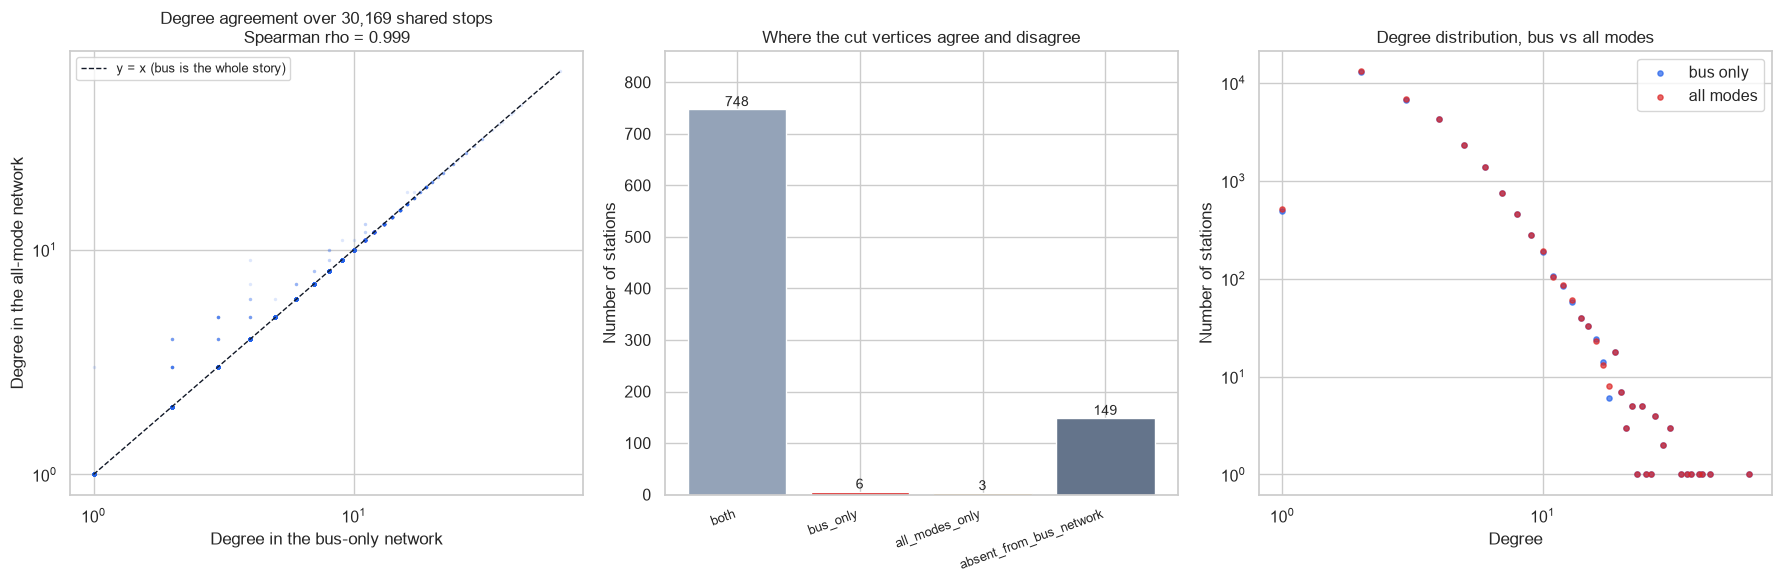

In [16]:
# --- Comparison figure ----------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = np.array([deg_bus[n] for n in shared_sorted], dtype=float)
y = np.array([deg_all[n] for n in shared_sorted], dtype=float)
axes[0].scatter(x, y, s=6, alpha=0.15, color='#2563eb', linewidths=0)
lim = max(x.max(), y.max())
axes[0].plot([1, lim], [1, lim], color='#111827', linestyle='--', linewidth=1,
             label='y = x (bus is the whole story)')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Degree in the bus-only network')
axes[0].set_ylabel('Degree in the all-mode network')
axes[0].set_title(f'Degree agreement over {len(shared_sorted):,} shared stops\n'
                  f'Spearman rho = {rho_degree:.3f}')
axes[0].legend(fontsize=9)

buckets = ['both', 'bus_only', 'all_modes_only', 'absent_from_bus_network']
counts = [len(ap_both), len(ap_bus_only), len(ap_all_only), len(ap_absent)]
bars = axes[1].bar(range(len(buckets)), counts,
                   color=['#94a3b8', '#dc2626', '#f59e0b', '#64748b'])
axes[1].set_xticks(range(len(buckets)))
axes[1].set_xticklabels(buckets, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('Number of stations')
axes[1].set_title('Where the cut vertices agree and disagree')
for bar, val in zip(bars, counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{val:,}',
                 ha='center', va='bottom', fontsize=10)
axes[1].margins(y=0.15)

for label, degmap, colour in [('bus only', deg_bus, '#2563eb'),
                              ('all modes', deg_all, '#dc2626')]:
    counts_by_deg = pd.Series(list(degmap.values())).value_counts().sort_index()
    counts_by_deg = counts_by_deg[counts_by_deg.index > 0]
    axes[2].scatter(counts_by_deg.index, counts_by_deg.to_numpy(), s=14, alpha=0.7,
                    color=colour, label=label)
axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_xlabel('Degree')
axes[2].set_ylabel('Number of stations')
axes[2].set_title('Degree distribution, bus vs all modes')
axes[2].legend()

plt.tight_layout()
plt.savefig(FIGURES / 'bus_vs_allmode.png', dpi=FIG_DPI)
plt.show()

## 17. Describe demand-responsive bus separately

We build the code-715 graph from the counters collected during the same stream and compare its station set and edge set with regular bus. We keep this as a one-row summary because flexible service does not have exactly the same edge meaning as a fixed scheduled route.

This layer has 153 stations, 194 undirected edges, and two components. Eighty-one stations are also served by regular bus, while 72 are unique to the demand-responsive layer. Its small total of 458 trips cannot change national aggregates much, but the unique-stop count shows that it can still matter for coverage.

In [17]:
# --- The demand-responsive layer, kept separate ---------------------------
drt_counts = edge_counts.get('drt', {})
if drt_counts:
    G_drt, D_drt = build_graphs(drt_counts)
    drt_components = sorted(nx.connected_components(G_drt), key=len, reverse=True)
    drt_nodes = set(G_drt.nodes())
    drt_summary = {
        'route_type': DRT_ROUTE_TYPE,
        'mode_label': MODE_LABELS[DRT_ROUTE_TYPE],
        'trips_streamed': stream_stats.get('drt_trips_streamed', 0),
        'stops': G_drt.number_of_nodes(),
        'directed_edges': D_drt.number_of_edges(),
        'undirected_edges': G_drt.number_of_edges(),
        'connected_components': len(drt_components),
        'largest_component_nodes': len(drt_components[0]),
        'stops_also_served_by_bus': len(drt_nodes & bus_nodes),
        'stops_unique_to_this_mode': len(drt_nodes - bus_nodes),
        'share_of_stops_shared_with_bus': round(len(drt_nodes & bus_nodes)
                                                / len(drt_nodes), 4),
        'edges_shared_with_bus': len({tuple(sorted(e)) for e in G_drt.edges()}
                                     & bus_edge_set),
    }
else:
    G_drt = nx.Graph()
    drt_summary = {'route_type': DRT_ROUTE_TYPE,
                   'mode_label': MODE_LABELS[DRT_ROUTE_TYPE],
                   'trips_streamed': 0, 'stops': 0, 'directed_edges': 0,
                   'undirected_edges': 0, 'connected_components': 0,
                   'largest_component_nodes': 0, 'stops_also_served_by_bus': 0,
                   'stops_unique_to_this_mode': 0,
                   'share_of_stops_shared_with_bus': None,
                   'edges_shared_with_bus': 0}
    print('No demand-responsive segments were found in the feed.')

pd.DataFrame([drt_summary]).to_csv(TABLES / 'demand_responsive_summary.csv',
                                   index=False, encoding='utf-8-sig')
for key, value in drt_summary.items():
    print(f'{key:34s} {value}')
print('\nsaved:', TABLES / 'demand_responsive_summary.csv')

route_type                         715
mode_label                         demand-responsive bus
trips_streamed                     458
stops                              153
directed_edges                     197
undirected_edges                   194
connected_components               2
largest_component_nodes            129
stops_also_served_by_bus           81
stops_unique_to_this_mode          72
share_of_stops_shared_with_bus     0.5294
edges_shared_with_bus              54

saved: /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/tables/demand_responsive_summary.csv


## 18. Save the bus-stage artifacts

We write the undirected bus graph as a pickle for convenient reuse and the directed edge list as a portable CSV. `bus_summary.json` collects the graph structure, comparison values, removal settings, and demand-responsive summary in one place. The cell checks every expected table, graph, summary, and figure and prints its file size.

All files stay inside `outputs/nb/15_bus_network/`, so another notebook can reuse the bus layer without another 816 MB scan.

In [18]:
# --- Persist the graph, the edge list and the summary ---------------------
with open(STAGE / 'bus_graph_undirected.pkl', 'wb') as f:
    pickle.dump(G_bus, f)

bus_edges_df = pd.DataFrame([{'from_stop': u, 'to_stop': v,
                              'trip_frequency': int(data['weight'])}
                             for u, v, data in D_bus.edges(data=True)])
bus_edges_df.to_csv(TABLES / 'bus_edges.csv', index=False, encoding='utf-8-sig')

resilience_headline = {
    row['strategy'] + f"_share_at_{row['removed']}_removed":
        row['largest_component_share']
    for _, row in resilience.iterrows()
    if row['removed'] in (100, 1000, 3000)
}

bus_summary = {
    'constants': {
        'BUS_ROUTE_TYPE': BUS_ROUTE_TYPE,
        'DRT_ROUTE_TYPE': DRT_ROUTE_TYPE,
        'K_BETWEENNESS': K_BETWEENNESS,
        'COMPUTE_ALLMODE_BETWEENNESS': COMPUTE_ALLMODE_BETWEENNESS,
        'SEED': SEED,
        'RANDOM_TRIALS': RANDOM_TRIALS,
        'REMOVAL_COUNTS': REMOVAL_COUNTS,
        'TOP_N': TOP_N,
    },
    'mode_inventory': inventory.to_dict('records'),
    'stream_stats': stream_stats,
    'bus_structure': bus_stats,
    'all_mode_structure': all_stats,
    'bus_vs_all_mode': overlap,
    'resilience_headline': resilience_headline,
    'demand_responsive': drt_summary,
}
with open(STAGE / 'bus_summary.json', 'w', encoding='utf-8') as f:
    json.dump(bus_summary, f, ensure_ascii=False, indent=2, default=str)

written = [STAGE / 'bus_graph_undirected.pkl', STAGE / 'bus_summary.json',
           TABLES / 'bus_station_metrics.csv', TABLES / 'bus_edges.csv',
           TABLES / 'top_bus_stations.csv', TABLES / 'bus_articulation_points.csv',
           TABLES / 'bus_bridges.csv', TABLES / 'bus_resilience.csv',
           TABLES / 'bus_vs_allmode_summary.csv',
           TABLES / 'articulation_point_comparison.csv',
           TABLES / 'demand_responsive_summary.csv',
           FIGURES / 'top_bus_stations.png', FIGURES / 'bus_resilience_curves.png',
           FIGURES / 'bus_vs_allmode.png']
print('Written:')
for p in written:
    flag = 'ok ' if p.exists() else 'MISSING '
    size = f'{p.stat().st_size / 1024:,.0f} KB' if p.exists() else ''
    print(f'  {flag}{p}  {size}')

Written:
  ok /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/bus_graph_undirected.pkl  3,678 KB
  ok /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/bus_summary.json  4 KB
  ok /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/tables/bus_station_metrics.csv  4,654 KB
  ok /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/tables/bus_edges.csv  754 KB
  ok /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/tables/top_bus_stations.csv  9 KB
  ok /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/tables/bus_articulation_points.csv  75 KB
  ok /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/tables/bus_bridges.csv  64 KB
  ok /Users/seanfourman/Desktop/israel-transit-network-resilience/outputs/nb/15_bus_network/tables/bus_resilience

## Conclusion

Regular bus is almost the whole merged network, and the direct comparison quantifies “almost.” It covers 99.03% of all-mode nodes and 99.26% of undirected edges. Shared-station degree has Spearman correlation 0.9991, 99.78% of shared stations have exactly the same degree, and 44 of the top 50 sampled-betweenness stations overlap. For broad structural patterns, the national graph and bus graph are nearly interchangeable.

The remaining difference is concentrated in identifiable cut points. The bus graph has 754 articulation points versus 900 in the all-mode graph. Of these, 748 are cut points in both, 6 appear only after we remove the non-bus layer, 3 bus stations are cut points only in the merged graph, and 149 all-mode cut points are outside the regular bus graph. The six `bus_only` rows are the places where a non-bus connection supplies enough alternative topology to hide a bus-specific vulnerability.

The bus network itself has one giant component containing 99.99% of its nodes, but it is not uniformly redundant. It still contains 812 bridges and 754 articulation points, with a median cut-vertex degree of only 3. That looks like a meshed core plus many vulnerable peripheral branches rather than one uniformly fragile national system.

The removal test shows the effect of targeting. After 3,000 random removals, the largest component retains about 86.2% of the original bus nodes. The targeted strategies leave roughly 34.7%-39.7%. These are static rankings, so an adaptive recalculation could do more damage, and the betweenness order has sampling uncertainty.

We also keep service and structure separate. High weighted degree, PageRank, betweenness, and cut-point status select different stations; only 12 of the 66 stations appearing in a top-20 centrality list are articulation points. For prioritization we need to decide whether we care about busy hubs, path bottlenecks, or branches with no alternative, rather than collapsing them into one score.

Finally, the graph is still a scheduled-supply model. It has no riders, no walking transfer between nearby stop IDs, no travel-time cost in the paths, and no time-of-day variation. The streaming pass also retained 562 local sequence-regression transitions, about 0.0036% of kept rows. That is unlikely to change the broad bus-versus-all-mode comparison, but we would skip those pairs before treating an exact edge or cut-point list as operational. The demand-responsive layer is small but reaches 72 stations not served by regular bus, which may matter for access even though it barely changes national topology.